<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/Telco_customer_churn_ipynb(Beginner_to_Adavance_EDA_%2B_Machine_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn .csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


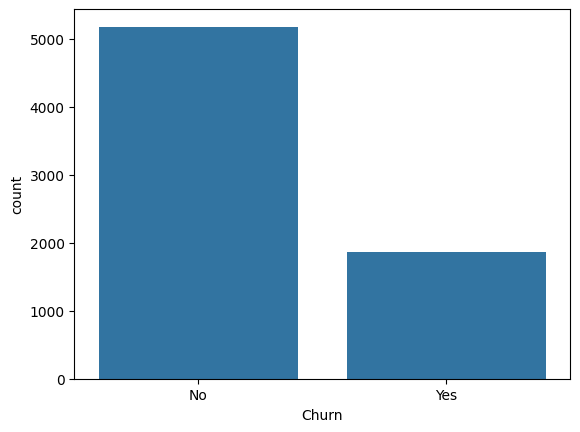

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()

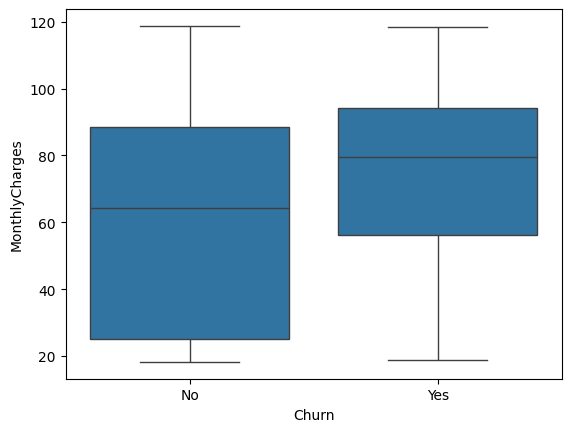

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()


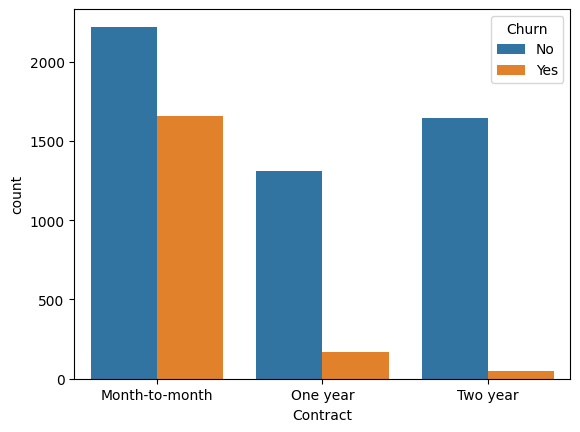

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [ ]:
df = df.drop('customerID', axis=1)

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [ ]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.8211497515968772

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



# Risk Levels

In [ ]:
proba = model.predict_proba(X_test)[:,1]

risk_level = pd.cut(
    proba,
    bins=[0,0.3,0.6,1],
    labels=['Low Risk','Medium Risk','High Risk']
)

risk_level.value_counts()

,count
Low Risk,871
Medium Risk,329
High Risk,209


### Key Insights
- Monthly contract users have highest churn
- High monthly charges increase churn risk
- Long tenure customers churn less

### Business Recommendations
- Offer discounts to monthly contract users
- Provide free tech support to high-risk customers
- Encourage yearly contracts


## New Complete EDA

## importing things to know

In [ ]:
# set options to be maximum for rows and columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
# Hide all wornings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.shape

(7043, 20)

In [ ]:
print(f'The number of rows are {df.shape[0]}, and the number of columns are {df.shape[1]}')

The number of rows are 7043, and the number of columns are 20


In [ ]:
print(f'The names of columns in this dataset are as follows: {df.columns}')

The names of columns in this dataset are as follows: Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
df_new = df.copy()

In [ ]:
df_new['gender'] = df_new['gender'].map({'Male': 1, 'Female': 2})

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df_new = df.copy()

# 1️⃣ YES / NO TYPE COLUMNS
yes_no_columns = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

yes_no_map = {
    'Yes': 1,
    'No': 2,
    'No internet service': 2,
    'No phone service': 2
}

for col in yes_no_columns:
    df_new[col] = (
        df_new[col]
        .astype(str)
        .str.strip()
        .map(yes_no_map)
        .fillna(0)
        .astype(int)
    )

# 2️⃣ INTERNET SERVICE COLUMN
internet_map = {
    'Fiber optic': 1,
    'DSL': 2,
    'No': 3
}

df_new['InternetService'] = (
    df_new['InternetService']
    .astype(str)
    .str.strip()
    .map(internet_map)
    .fillna(0)
    .astype(int)
)


In [ ]:
df_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,2,1,2,2,2,2,1,2,2,2,2,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,2,34,1,2,2,1,2,1,2,2,2,One year,2,Mailed check,56.95,1889.50,0
2,1,0,0,2,2,1,2,2,1,1,2,2,2,2,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,2,45,2,2,2,1,2,1,1,2,2,One year,2,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,2,2,1,2,1,2,2,2,2,2,2,Month-to-month,1,Electronic check,70.70,151.65,1


In [ ]:
X = df_new.drop('Churn', axis=1)   # ya 'Churn Label'
y = df_new['Churn']               # 1 = Yes, 0 = No

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
cat_cols = df_new.select_dtypes(include='object').columns
cat_cols

Index(['Contract', 'PaymentMethod'], dtype='object')

In [ ]:
df_final = pd.get_dummies(df_new, columns=cat_cols, drop_first=True)

In [ ]:
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8034066713981547
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



## 📊 Model 1 Report
Logistic Regression (Baseline Model)
1. Model Objective

The main goal of this model is to predict customer churn.
Customer churn means a customer leaves the company.

This model helps the company:

Identify customers who may leave

Take action before losing them

2. Dataset Description

The dataset contains customer information, such as:

Demographics (Gender, Senior Citizen, Partner, Dependents)

Services used (Internet Service, Streaming, Tech Support)

Account details (Contract type, Monthly Charges, Tenure)

Target variable: Churn

The target variable:

0 = Customer did NOT churn

1 = Customer churned

3. Data Preprocessing

Before training the model, the following steps were applied:

Missing values were handled

Categorical values (Yes/No, Male/Female) were converted into numbers

Multi-category columns were encoded using One-Hot Encoding

All text values were removed so the model receives only numeric data

4. Model Selection

Logistic Regression was selected as the baseline model because:

It is simple and fast

Easy to understand and explain

Widely used for binary classification problems

5. Model Training

The data was split into 80% training and 20% testing

The model was trained using the training dataset

Predictions were made on the test dataset

6. Model Performance
🔹 Accuracy
Accuracy: 80%


This means the model correctly predicted churn for 8 out of 10 customers.

🔹 Classification Report
Class	Precision	Recall	F1-Score
Not Churn (0)	0.85	0.89	0.87
Churn (1)	0.65	0.55	0.60
7. Result Analysis

The model performs very well for customers who do not churn

The model correctly identifies 55% of churn customers

Accuracy is good, but churn recall needs improvement

8. Business Insight

In churn prediction:

Recall for churn customers is very important

Missing a churn customer can cause financial loss

This baseline model gives a strong starting point and can be improved using:

Class balancing

Advanced machine learning models

9. Conclusion

Logistic Regression achieved 80% accuracy

The model is suitable as a baseline

Further improvements can increase churn detection

10. Next Steps

Improve recall using class-weighted models

Train advanced models like Random Forest or XGBoost

Analyze important features affecting churn

✅ Final Note

This model provides a clear and simple foundation for customer churn prediction and can be used as a reference for more advanced models.